==================================================
                 TASK SUBMISSION
==================================================

Full Name:         Pranav Rase
Internship Track:  Data Analytics
Task Title:        Task 2 - Customer Segmentation Analysis

==================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
print("Loading dataset...")
df = pd.read_excel('Online Retail.xlsx')

print("\n--- Initial Dataset Overview ---")
print(df.info())

Loading dataset...

--- Initial Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB
None


In [3]:
# Drop records without Customer ID
df_clean = df.dropna(subset=['CustomerID']).copy()

# Filter out negative quantities (returns/cancellations) and non-positive prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Correct data types
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Calculate Total Purchase Value per line item
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("--- Basic E-Commerce Descriptive Statistics ---")
print(f"Total Transactions: {df_clean['InvoiceNo'].nunique():,}")
print(f"Total Unique Customers: {df_clean['CustomerID'].nunique():,}")
print(f"Average Order Value (AOV): ${df_clean.groupby('InvoiceNo')['TotalSum'].sum().mean():.2f}")

--- Basic E-Commerce Descriptive Statistics ---
Total Transactions: 18,532
Total Unique Customers: 4,338
Average Order Value (AOV): $480.87


In [4]:
# Define snapshot date as 1 day after the latest transaction date in dataset
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate customer metrics
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalSum': 'sum'                                       # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("--- RFM Summary Statistics ---")
print(rfm.describe().T[['mean', 'std', 'min', '50%', 'max']].rename(columns={'50%': 'median'}))

--- RFM Summary Statistics ---
                    mean          std       min     median        max
CustomerID  15300.408022  1721.808492  12346.00  15299.500   18287.00
Recency        92.536422   100.014169      1.00     51.000     374.00
Frequency       4.272015     7.697998      1.00      2.000     209.00
Monetary     2054.266460  8989.230441      3.75    674.485  280206.02


In [5]:
# RFM metrics are right-skewed; apply log transformation to normalize scale
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# Scale variables using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

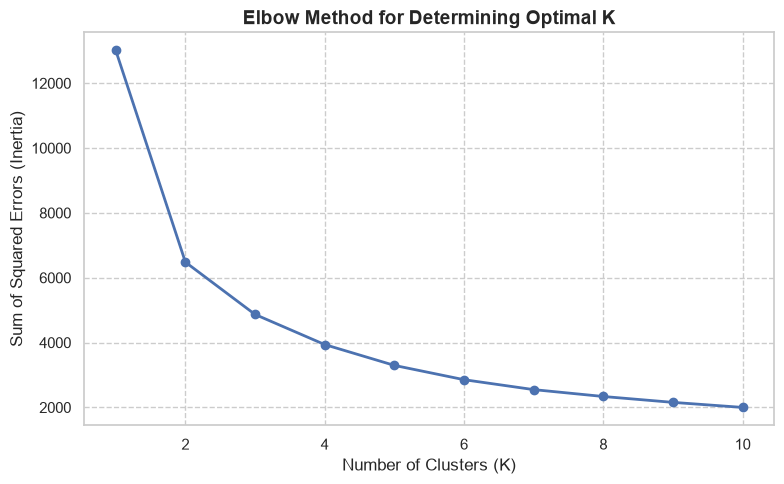

In [6]:
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse[k] = kmeans.inertia_

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(list(sse.keys()), list(sse.values()), marker='o', color='b', linewidth=2)
plt.title('Elbow Method for Determining Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (Inertia)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [7]:
# Based on elbow point, select K = 3
K_OPTIMAL = 3
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [8]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).reset_index()

# Flatten columns
cluster_profile.columns = ['Cluster', 'Mean_Recency', 'Mean_Frequency', 'Mean_Monetary', 'Customer_Count']

# Assign descriptive profile names based on cluster metrics
cluster_names = {
    0: "Champions / High-Value Loyalists",
    1: "Lost / At-Risk Customers",
    2: "Potential Loyalists / Regular Buyers"
}
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

print("--- Cluster Profiles ---")
print(cluster_profile.to_string(index=False))

--- Cluster Profiles ---
 Cluster  Mean_Recency  Mean_Frequency  Mean_Monetary  Customer_Count
       0     17.063636       13.338961    7905.440519             770
       1    167.361111        1.352030     362.537613            1872
       2     44.212264        3.378538    1265.063852            1696


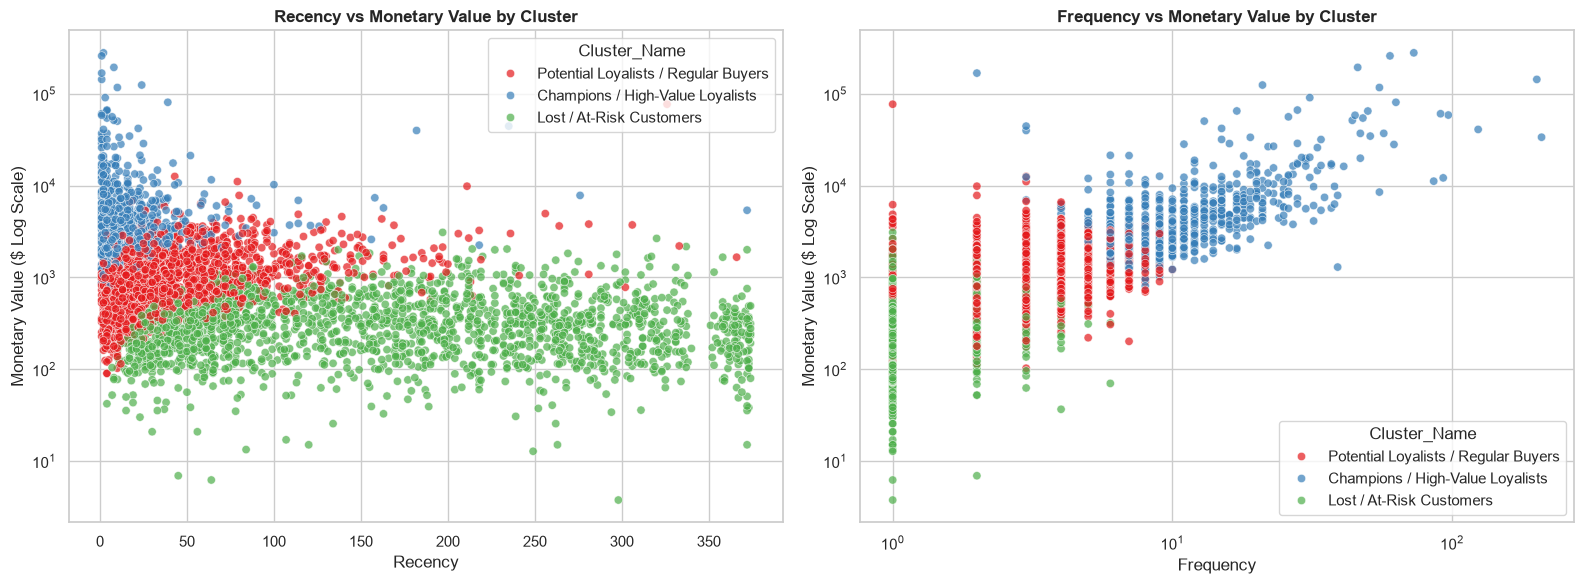

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot 1: Recency vs Monetary (Log scale)
sns.scatterplot(
    data=rfm, x='Recency', y='Monetary', hue='Cluster_Name', 
    palette='Set1', alpha=0.7, ax=axes[0]
)
axes[0].set_title('Recency vs Monetary Value by Cluster', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Monetary Value ($ Log Scale)')

# Scatter Plot 2: Frequency vs Monetary (Log scale)
sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary', hue='Cluster_Name', 
    palette='Set1', alpha=0.7, ax=axes[1]
)
axes[1].set_title('Frequency vs Monetary Value by Cluster', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_ylabel('Monetary Value ($ Log Scale)')

plt.tight_layout()
plt.show()

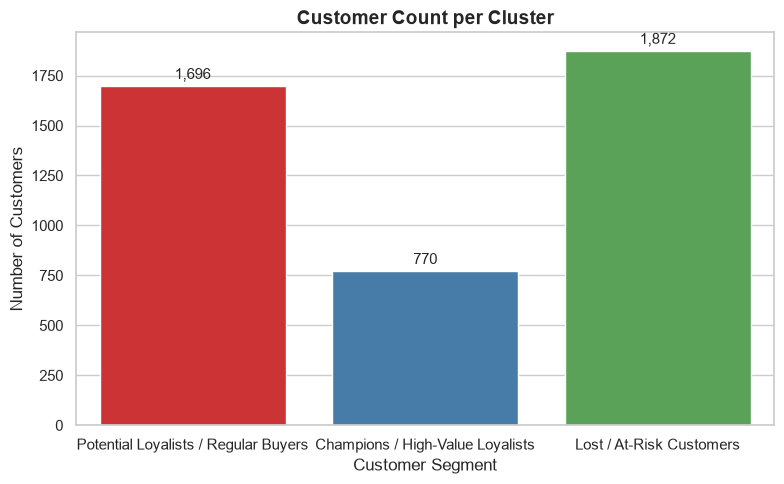

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=rfm, 
    x='Cluster_Name', 
    hue='Cluster_Name', # Explicit hue assignment to prevent warning
    legend=False, 
    palette='Set1'
)
plt.title('Customer Count per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [11]:
print("================================================================================")
print("                    ACTIONABLE MARKETING STRATEGIES BY SEGMENT                  ")
print("================================================================================")
print("1. CHAMPIONS / HIGH-VALUE LOYALISTS (Cluster 0)")
print("   - Profile: Low Recency (~17 days), High Frequency (~13 orders), High Spend (~$7,905).")
print("   - Marketing Action:")
print("     * Enroll in exclusive VIP membership programs with priority customer support.")
print("     * Early access to new product releases and premium upsell opportunities.")
print("     * Request product reviews and referrals to drive word-of-mouth acquisition.\n")
print("2. POTENTIAL LOYALISTS / REGULAR BUYERS (Cluster 2)")
print("   - Profile: Moderate Recency (~44 days), Average Frequency (~3 orders), Moderate Spend (~$1,265).")
print("   - Marketing Action:")
print("     * Implement targeted cross-sell and bundle recommendations based on purchase history.")
print("     * Offer tiered discount thresholds (e.g., 'Spend $150 to get $20 off') to increase Average Order Value.\n")
print("3. LOST / AT-RISK CUSTOMERS (Cluster 1)")
print("   - Profile: High Recency (~167 days), Low Frequency (~1 order), Low Spend (~$362).")
print("   - Marketing Action:")
print("     * Deploy win-back automated email sequences featuring limited-time discount incentives.")
print("     * Send brief feedback surveys to identify reasons for attrition.")
print("================================================================================")

                    ACTIONABLE MARKETING STRATEGIES BY SEGMENT                  
1. CHAMPIONS / HIGH-VALUE LOYALISTS (Cluster 0)
   - Profile: Low Recency (~17 days), High Frequency (~13 orders), High Spend (~$7,905).
   - Marketing Action:
     * Enroll in exclusive VIP membership programs with priority customer support.
     * Early access to new product releases and premium upsell opportunities.
     * Request product reviews and referrals to drive word-of-mouth acquisition.

2. POTENTIAL LOYALISTS / REGULAR BUYERS (Cluster 2)
   - Profile: Moderate Recency (~44 days), Average Frequency (~3 orders), Moderate Spend (~$1,265).
   - Marketing Action:
     * Implement targeted cross-sell and bundle recommendations based on purchase history.
     * Offer tiered discount thresholds (e.g., 'Spend $150 to get $20 off') to increase Average Order Value.

3. LOST / AT-RISK CUSTOMERS (Cluster 1)
   - Profile: High Recency (~167 days), Low Frequency (~1 order), Low Spend (~$362).
   - Marketing 